In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# Final Model Comparison
# ============================

results = [
    {
        "Model": "KNN",
        "Category": "Distance-Based",
        "Accuracy": 0.2443,
        "Precision": 0.2418,
        "Recall": 0.2443,
        "F1-score": 0.2254,
        "Split": "GroupSplit",
        "Notes": "Baseline distance-based model"
    },
    {
        "Model": "Decision Tree",
        "Category": "Tree-Based",
        "Accuracy": 0.3038,
        "Precision": 0.3182,
        "Recall": 0.3038,
        "F1-score": 0.3026,
        "Split": "GroupSplit",
        "Notes": "GridSearchCV tuned"
    },
    {
        "Model": "Linear SVM + PCA 50",
        "Category": "Linear",
        "Accuracy": 0.379375,
        "Precision": 0.403576,
        "Recall": 0.379375,
        "F1-score": 0.342244,
        "Split": "GroupSplit 4-Class",
        "Notes": "Best SVM result using PCA with 50 components"
    },
    {
        "Model": "Random Forest",
        "Category": "Ensemble",
        "Accuracy": 0.7691,
        "Precision": 0.7607,
        "Recall": 0.7591,
        "F1-score": 0.7044,
        "Split": "GroupSplit 3-Class",
        "Notes": "Best traditional model, 3-class"
    },
    {
        "Model": "MLP Neural Network",
        "Category": "Neural Network",
        "Accuracy": 0.5287,
        "Precision": 0.5797,
        "Recall": 0.5287,
        "F1-score": 0.5117,
        "Split": "GroupSplit 3-Class",
        "Notes": "PCA + neural network"
    },
    {
        "Model": "CNN-BiLSTM",
        "Category": "Deep Learning",
        "Accuracy": 0.5419,
        "Precision": 0.5400,
        "Recall": 0.5419,
        "F1-score": 0.5401,
        "Split": "GroupSplit 4-Class",
        "Notes": "Deep learning model, 4-class"
    },
    {
        "Model": "XGBoost",
        "Category": "Boosting",
        "Accuracy": 0.3860,
        "Precision": 0.4262,
        "Recall": 0.3860,
        "F1-score": 0.3820,
        "Split": "Subject-Dependent 4-Class",
        "Notes": "Best params: n_estimators=400, max_depth=4, learning_rate=0.01"
    }
]

df_results = pd.DataFrame(results)

comparison = df_results.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

comparison["Rank"] = comparison.index + 1

comparison = comparison[
    [
        "Rank",
        "Model",
        "Category",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Split",
        "Notes"
    ]
]

comparison

,Rank,Model,Category,Accuracy,Precision,Recall,F1-score,Split,Notes
0,1,Random Forest,Ensemble,0.769100,0.760700,0.759100,0.704400,GroupSplit 3-Class,"Best traditional model, 3-class"
1,2,CNN-BiLSTM,Deep Learning,0.541900,0.540000,0.541900,0.540100,GroupSplit 4-Class,"Deep learning model, 4-class"
2,3,MLP Neural Network,Neural Network,0.528700,0.579700,0.528700,0.511700,GroupSplit 3-Class,PCA + neural network
3,4,XGBoost,Boosting,0.386000,0.426200,0.386000,0.382000,Subject-Dependent 4-Class,"Best params: n_estimators=400, max_depth=4, le..."
4,5,Linear SVM + PCA 50,Linear,0.379375,0.403576,0.379375,0.342244,GroupSplit 4-Class,Best SVM result using PCA with 50 components
5,6,Decision Tree,Tree-Based,0.303800,0.318200,0.303800,0.302600,GroupSplit,GridSearchCV tuned
6,7,KNN,Distance-Based,0.244300,0.241800,0.244300,0.225400,GroupSplit,Baseline distance-based model


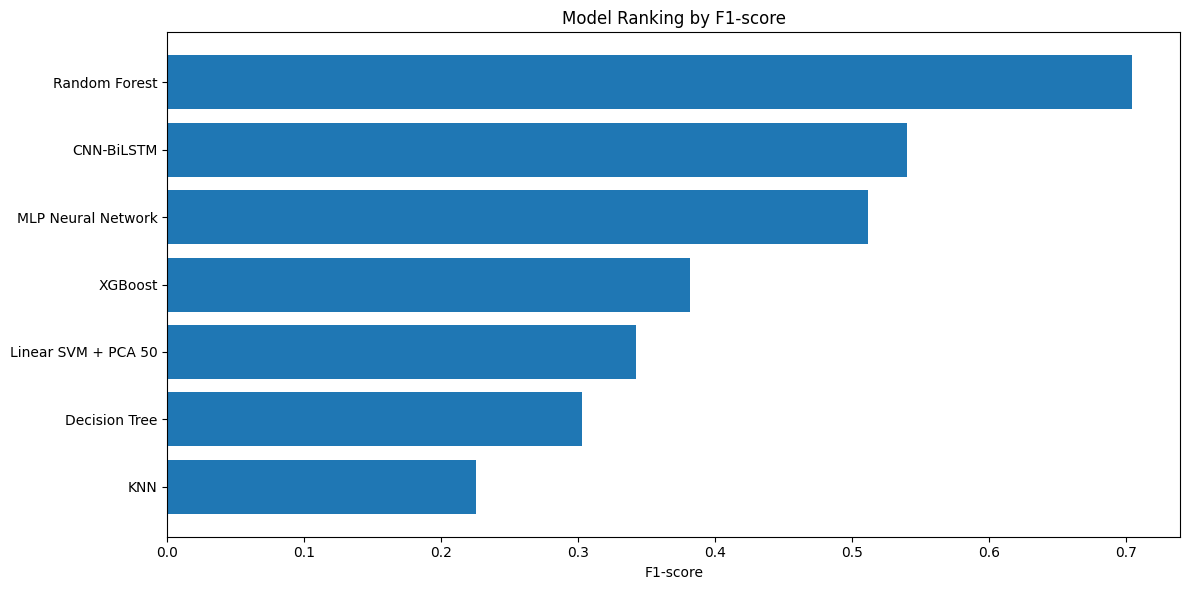

In [ ]:
#Horizontal Ranking Chart
plt.figure(figsize=(12,6))

ranking = comparison.sort_values("F1-score", ascending=True)

plt.barh(
    ranking["Model"],
    ranking["F1-score"]
)

plt.title("Model Ranking by F1-score")
plt.xlabel("F1-score")

plt.tight_layout()
plt.show()

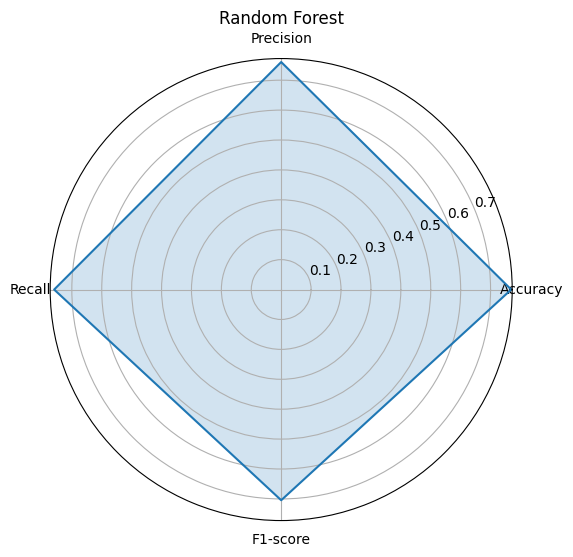

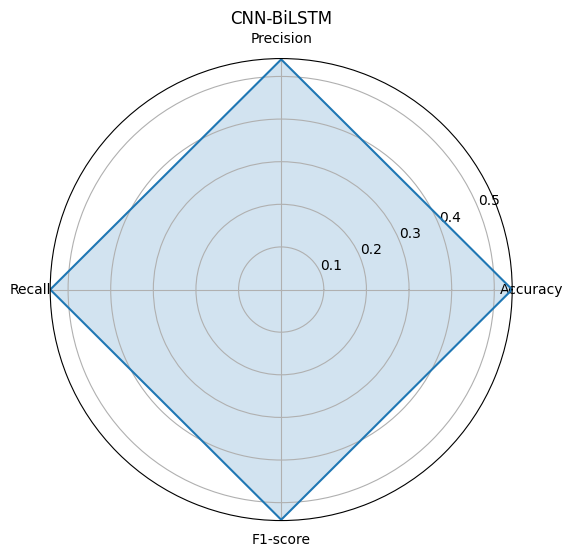

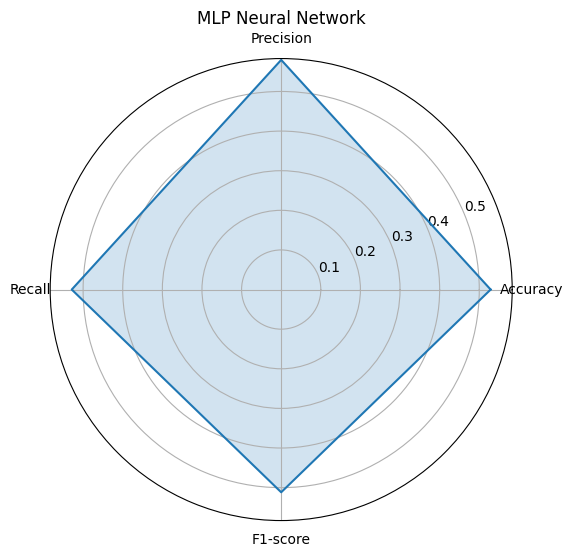

In [6]:
import numpy as np

best_models = comparison.head(3)

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

for _, row in best_models.iterrows():

    values = row[metrics].tolist()
    values += values[:1]

    angles = np.linspace(
        0,
        2*np.pi,
        len(metrics),
        endpoint=False
    ).tolist()

    angles += angles[:1]

    fig = plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.2)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)

    plt.title(row["Model"])
    plt.show()

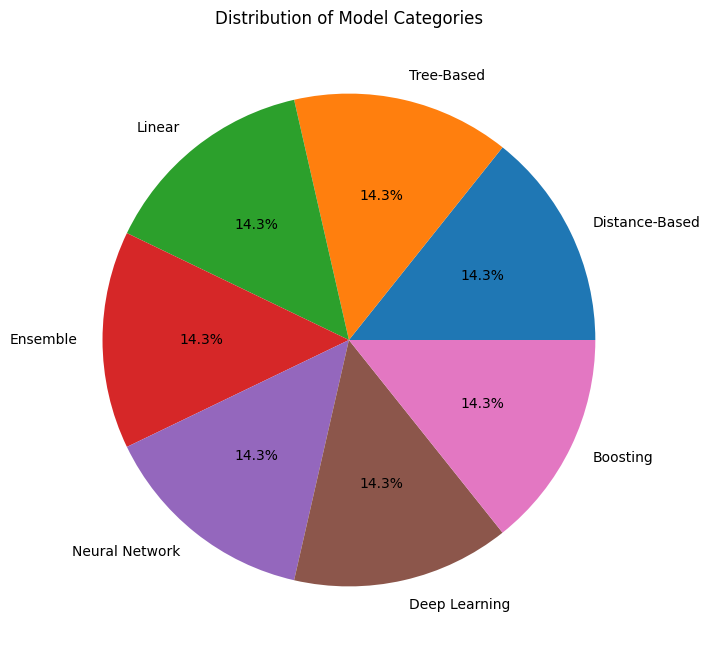

In [8]:
category_counts = df_results["Category"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%"
)

plt.title("Distribution of Model Categories")

plt.show()

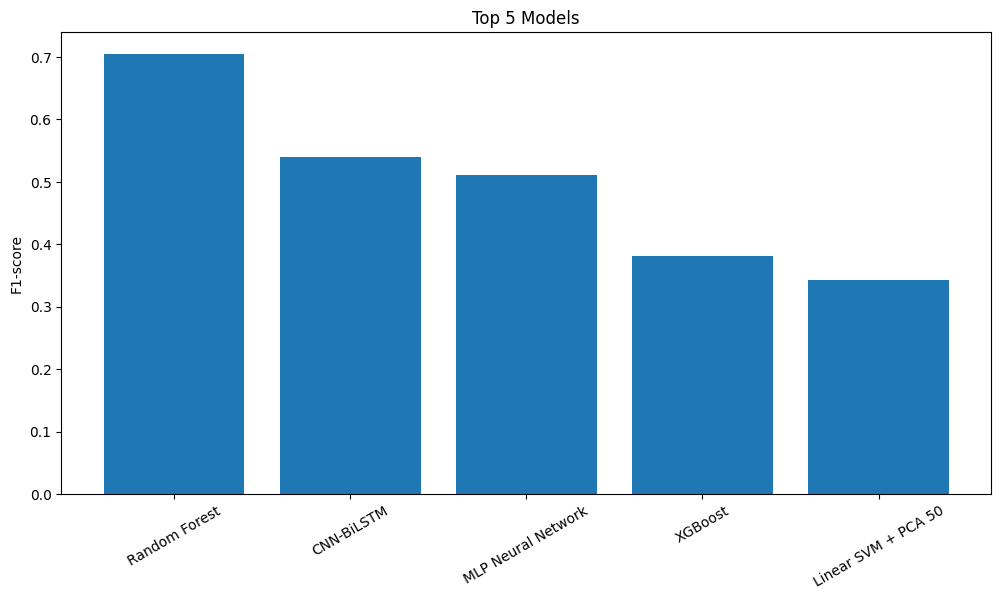

In [9]:
top_models = comparison.head(5)

plt.figure(figsize=(12,6))

plt.bar(
    top_models["Model"],
    top_models["F1-score"]
)

plt.title("Top 5 Models")
plt.ylabel("F1-score")

plt.xticks(rotation=30)

plt.show()

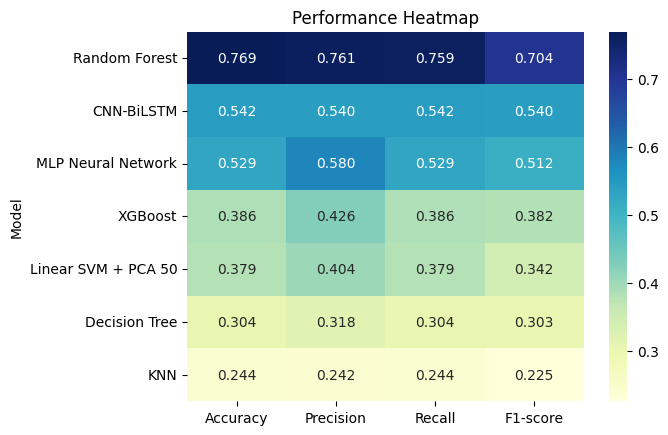

In [10]:
sns.heatmap(
    comparison.set_index("Model")[
        ["Accuracy","Precision","Recall","F1-score"]
    ],
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("Performance Heatmap")

plt.show()

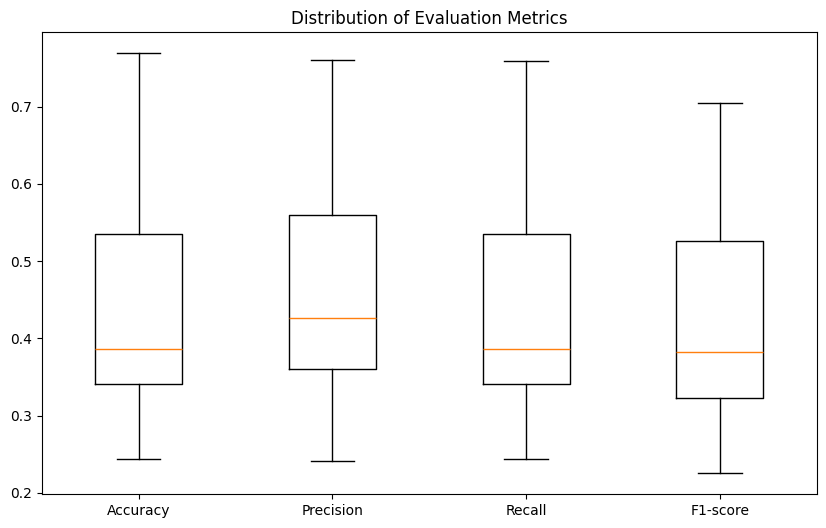

In [11]:
metrics = ["Accuracy","Precision","Recall","F1-score"]

plt.figure(figsize=(10,6))

plt.boxplot(
    [comparison[m] for m in metrics],
    tick_labels=metrics
)

plt.title("Distribution of Evaluation Metrics")

plt.show()

In [12]:
styled_comparison = comparison.style \
    .background_gradient(
        subset=["Accuracy", "Precision", "Recall", "F1-score"],
        cmap="YlGnBu"
    ) \
    .format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1-score": "{:.3f}"
    }) \
    .set_caption("Final Model Comparison - NeuroSense") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1f4e79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("padding", "8px")
            ]
        }
    ])

styled_comparison

,Rank,Model,Category,Accuracy,Precision,Recall,F1-score,Split,Notes
0,1,Random Forest,Ensemble,0.769,0.761,0.759,0.704,GroupSplit 3-Class,"Best traditional model, 3-class"
1,2,CNN-BiLSTM,Deep Learning,0.542,0.540,0.542,0.540,GroupSplit 4-Class,"Deep learning model, 4-class"
2,3,MLP Neural Network,Neural Network,0.529,0.580,0.529,0.512,GroupSplit 3-Class,PCA + neural network
3,4,XGBoost,Boosting,0.386,0.426,0.386,0.382,Subject-Dependent 4-Class,"Best params: n_estimators=400, max_depth=4, learning_rate=0.01"
4,5,Linear SVM + PCA 50,Linear,0.379,0.404,0.379,0.342,GroupSplit 4-Class,Best SVM result using PCA with 50 components
5,6,Decision Tree,Tree-Based,0.304,0.318,0.304,0.303,GroupSplit,GridSearchCV tuned
6,7,KNN,Distance-Based,0.244,0.242,0.244,0.225,GroupSplit,Baseline distance-based model
